# Explicit Debiasing Analysis

All plots are restricted to `explicit_debiasing=True` (warn prompt).
Two sections:
- **Section A** — `explore_instruction=False` (warn prompt, no explore instruction)
- **Section B** — `explore_instruction=True` (warn prompt, with explore instruction)

Visualizations mirror `label_channel_bias.ipynb` and `reward_channel_bias.ipynb`.
Run `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {'linestyle': '--', 'color': 'black',    'label': 'Maximum'},
    'min_val': {'linestyle': '--', 'color': 'firebrick','label': 'Minimum'},
}

NOM_STYLE_CONSTANTS = {
    'alphanumeric':     {'color': 'black',      'linestyle': '-', 'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'color': 'steelblue',  'linestyle': '-', 'marker': 'o', 'label': 'Ordinal - Misleading'},
    'world_helpful':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':    {'color': 'darkgreen',  'linestyle': '-', 'marker': 'o', 'label': 'World - Misleading'},
    'sent_new_helpful': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'color': 'darkorchid', 'linestyle': '-', 'marker': 'o', 'label': 'Sentiment - Misleading'},
}

NOM_STYLE_MISLEAD_EXPLOR = {
    'ordinal_mislead':  {'color': 'cornflowerblue', 'linestyle': ':', 'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_mislead':    {'color': 'mediumseagreen',  'linestyle': ':', 'marker': '^', 'label': 'World - Misleading'},
    'sent_new_mislead': {'color': 'orchid',          'linestyle': ':', 'marker': '^', 'label': 'Sentiment - Misleading'},
}

NOM_Y_JITTER = {
    'alphanumeric':      0.000,
    'ordinal_helpful':  -0.015,
    'ordinal_mislead':  -0.010,
    'world_helpful':    -0.005,
    'world_mislead':     0.005,
    'sent_new_helpful':  0.010,
    'sent_new_mislead':  0.015,
}

nom_legend_order = [
    'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    'sent_new_helpful', 'sent_new_mislead',
]

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':        'Scaled Cum. Regret',
    'exploration_count': 'Actions Explored',
}

SCALE_NOM_COLORS = {
    'high_scale': {
        'alphanumeric':     '#7B241C',
        'ordinal_helpful':  '#CA6F1E', 'ordinal_mislead':  '#CA6F1E',
        'world_helpful':    '#F0B27A', 'world_mislead':    '#F0B27A',
        'sent_new_helpful': '#8B4513', 'sent_new_mislead': '#8B4513',
    },
    'low_scale': {
        'alphanumeric':     '#7B241C',
        'ordinal_helpful':  '#CA6F1E', 'ordinal_mislead':  '#CA6F1E',
        'world_helpful':    '#F0B27A', 'world_mislead':    '#F0B27A',
        'sent_new_helpful': '#8B4513', 'sent_new_mislead': '#8B4513',
    },
    'high_neg_scale': {
        'alphanumeric':     '#1A5276',
        'ordinal_helpful':  '#2E86C1', 'ordinal_mislead':  '#2E86C1',
        'world_helpful':    '#85C1E9', 'world_mislead':    '#85C1E9',
        'sent_new_helpful': '#4682B4', 'sent_new_mislead': '#4682B4',
    },
    'low_neg_scale': {
        'alphanumeric':     '#1A5276',
        'ordinal_helpful':  '#2E86C1', 'ordinal_mislead':  '#2E86C1',
        'world_helpful':    '#85C1E9', 'world_mislead':    '#85C1E9',
        'sent_new_helpful': '#4682B4', 'sent_new_mislead': '#4682B4',
    },
}

SCALE_LABELS = {
    'high_scale': 'High+', 'low_scale': 'Low+',
    'high_neg_scale': 'High\u2212', 'low_neg_scale': 'Low\u2212',
}

NOM_STYLES = {
    'alphanumeric':     {'marker': 'o', 'linestyle': ':',  'label': 'Alphanumeric'},
    'ordinal_helpful':  {'marker': 's', 'linestyle': '-',  'label': 'Ordinal - Helpful'},
    'ordinal_mislead':  {'marker': 's', 'linestyle': '-',  'label': 'Ordinal - Misleading'},
    'world_helpful':    {'marker': '^', 'linestyle': '--', 'label': 'World - Helpful'},
    'world_mislead':    {'marker': '^', 'linestyle': '--', 'label': 'World - Misleading'},
    'sent_new_helpful': {'marker': 'D', 'linestyle': '-.', 'label': 'Sentiment - Helpful'},
    'sent_new_mislead': {'marker': 'D', 'linestyle': '-.', 'label': 'Sentiment - Misleading'},
}

UCB1_STYLE = {'color': '#C8A800', 'linestyle': '--', 'linewidth': 1.5, 'label': 'UCB1'}

## Configuration

In [4]:
# Load merged results and restrict to explicit debiasing condition
_all_results = pd.read_csv('experiments/merged_sem_var_results.csv')
for col in ('explicit_debiasing', 'explore_instruction'):
    if col not in _all_results.columns:
        raise RuntimeError(f"{col} column missing — re-run data_processing.ipynb first.")

# Baseline rows (UCB1/TS) kept separately for reference lines
_baseline_all = _all_results.copy()

# Working set: explicit debiasing only
_debiased = _all_results[_all_results['explicit_debiasing'] == True].copy()
print(f"explicit_debiasing=True rows: {len(_debiased)}")
_debiased[['domain', 'model', 'explore_instruction', 'variance']].value_counts().reset_index(name='count')

explicit_debiasing=True rows: 308


,domain,model,explore_instruction,variance,count
0,Clothing Recommendation,Qwen3-32B,True,No,28
1,Clothing Recommendation,Olmo-3.1-32B-Instruct,True,No,28
2,Farm,Qwen3-32B,True,No,28
3,Farm,Olmo-3.1-32B-Instruct,True,No,28
4,Clothing Recommendation,gemini-3.1-flash-lite-preview,True,No,28
5,Farm,gemini-3.1-flash-lite-preview,True,No,28
6,Bandit,Olmo-3.1-32B-Instruct,True,No,20
7,Bandit,gemini-3.1-flash-lite-preview,True,No,20
8,Bandit,Qwen3-32B,True,No,20
9,Farm,Olmo-3.1-32B-Instruct,False,No,14


In [5]:
SCALE = 'high_scale'

nom_groups = {
    'helpful': ['alphanumeric', 'ordinal_helpful', 'world_helpful', 'sent_new_helpful'],
    'mislead': ['alphanumeric', 'ordinal_mislead', 'world_mislead', 'sent_new_mislead'],
}

domain_order   = ['Bandit', 'Farm', 'Clothing Recommendation']
DOMAIN_DISPLAY = {'Bandit': 'Bandit', 'Farm': 'Farm', 'Clothing Recommendation': 'Clothing'}
all_variances  = ['No', 'Low', 'High']
hist           = 'Summarized'

present_domains = _debiased['domain'].unique()
domains = [d for d in domain_order if d in present_domains and d != 'Classical']

turn_numbers = sorted(
    int(col.split('_')[-2])
    for col in _debiased.columns
    if col.startswith('cum_regret_') and col.endswith('_mean')
)

SCALE_GROUPS = [
    ['high_scale', 'high_neg_scale'],
    ['low_scale',  'low_neg_scale'],
]

target_nomenclatures = ['alphanumeric', 'ordinal_mislead', 'world_mislead', 'sent_new_mislead']

_jitter_combos = [(nom, scale) for nom in target_nomenclatures for scale in ['high_scale', 'high_neg_scale']]
_jitter_step   = 0.01
_jitter_offsets = {
    combo: (i - (len(_jitter_combos) - 1) / 2) * _jitter_step
    for i, combo in enumerate(_jitter_combos)
}

THREE_MODELS = [
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('Qwen3-32B',                    'Qwen3-32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]

DOMAIN_ORDER   = ['Bandit', 'Farm', 'Clothing Recommendation']
VARIANCE_ORDER = ['No', 'Low', 'High']

print(f"Domains: {domains}")
print(f"Turn numbers: {turn_numbers}")

Domains: ['Bandit', 'Farm', 'Clothing Recommendation']
Turn numbers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Plotting helpers

In [6]:
def fmt(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return '--'
    return f'{val:.2f}'


def build_latex_table(df, present_doms, include_variance_col, scale, variance_filter):
    n_meta    = 3 if include_variance_col else 2
    meta_spec = 'llr' if include_variance_col else 'lr'
    col_spec  = meta_spec + ''.join(['|rr' for _ in present_doms])

    llm_df = df[df['Nomenclature'] != '']
    bold_H, bold_M = {}, {}
    for domain in present_doms:
        dcol = DOMAIN_DISPLAY[domain]
        for model in llm_df['Model'].unique():
            for variance in llm_df['Variance'].unique():
                mdf    = llm_df[(llm_df['Model'] == model) & (llm_df['Variance'] == variance)]
                h_vals = mdf[f'{dcol} H'].dropna()
                m_vals = mdf[f'{dcol} M'].dropna()
                if not h_vals.empty:
                    bold_H[(model, dcol, variance)] = h_vals.min()
                if not m_vals.empty:
                    bold_M[(model, dcol, variance)] = m_vals.max()

    def fmt_bold(val, target):
        s = fmt(val)
        if s == '--' or target is None:
            return s
        if abs(float(val) - target) < 1e-9:
            return r'\textbf{' + s + r'}'
        return s

    lines = []
    lines.append(r'\resizebox{\columnwidth}{!}{%')
    lines.append(r'\begin{tabular}{' + col_spec + r'}')
    lines.append(r'\toprule')
    header1 = [''] * n_meta + [r'\multicolumn{2}{c}{' + DOMAIN_DISPLAY[d] + r'}' for d in present_doms]
    lines.append(' & '.join(header1) + r' \\')
    cmidrules = []
    for i in range(len(present_doms)):
        c1 = n_meta + 1 + i * 2
        c2 = c1 + 1
        cmidrules.append(r'\cmidrule(lr){' + f'{c1}-{c2}' + r'}')
    lines.append(' '.join(cmidrules))
    header2 = ['Model', 'Variance', 'Nomenclature'] if include_variance_col else ['Model', 'Nomenclature']
    for _ in present_doms:
        header2 += ['Helpful', 'Misleading']
    lines.append(' & '.join(header2) + r' \\')
    lines.append(r'\midrule')

    prev_model    = None
    prev_variance = None
    for _, row in df.iterrows():
        is_new_model    = (row['Model']    != prev_model)
        is_new_variance = (row['Variance'] != prev_variance)
        if prev_model is not None and is_new_model:
            lines.append(r'\midrule')
        model_cell = row['Model'] if is_new_model else ''
        cells = [model_cell]
        if include_variance_col:
            variance_cell = row['Variance'] if (is_new_model or is_new_variance) else ''
            cells.append(variance_cell)
        prev_model    = row['Model']
        prev_variance = row['Variance']
        cells.append(row['Nomenclature'])
        for domain in present_doms:
            dcol  = DOMAIN_DISPLAY[domain]
            h_val = row.get(f'{dcol} H')
            m_val = row.get(f'{dcol} M')
            key   = (row['Model'], dcol, row['Variance'])
            cells.append(fmt_bold(h_val, bold_H.get(key)))
            cells.append(fmt_bold(m_val, bold_M.get(key)))
        lines.append(' & '.join(cells) + r' \\')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}%')
    lines.append(r'}')
    return '\n'.join(lines)


def wrap_table(tabular_str, scale, variance_label, section_label):
    scale_note = scale.replace('_', r'\_')
    return '\n'.join([
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        tabular_str,
        r'\caption{Normalized cumulative regret at the final turn (' + section_label + r'), by model'
        + (', variance condition,' if variance_label == 'all' else '')
        + r' and nomenclature type. H\,=\,helpful framing; M\,=\,misleading framing. '
        + r'Scale: ' + scale_note + r'; variance: ' + variance_label + r'.}',
        r'\label{tab:explicit_debiasing_' + section_label.replace(' ', '_') + r'_' + variance_label.replace(' ', '_') + r'}',
        r'\end{table}',
    ])


NOM_ROWS = [
    ('Ordinal',      'ordinal_helpful',  'ordinal_mislead'),
    ('World',        'world_helpful',    'world_mislead'),
    ('Sentiment',    'sent_new_helpful', 'sent_new_mislead'),
    ('Alphanumeric', 'alphanumeric',     None),
]
MODELS_TO_INCLUDE = [
    ('Qwen3-32B',                    'Qwen3-32B'),
    ('Olmo-3.1-32B-Instruct',        'OLMo-3.1 32B'),
    ('gemini-3.1-flash-lite-preview', 'Gemini 3.1 Flash Lite'),
]
last_turn            = max(turn_numbers)
normalizing_constant = (max(rewards_per_scale[SCALE]) - min(rewards_per_scale[SCALE])) * len(turn_numbers)


def make_table_df(results_df):
    mask = (results_df['history'] == 'Summarized') & (results_df['scale'] == SCALE)
    df   = results_df[mask & results_df['domain'].isin(domains)].copy()
    df   = df[df['model'].isin([m[0] for m in MODELS_TO_INCLUDE])]
    present_doms = [d for d in DOMAIN_ORDER if d in df['domain'].unique()]
    rows = []
    for model_id, mlabel in MODELS_TO_INCLUDE:
        for variance in VARIANCE_ORDER:
            for nom_label, helpful_key, mislead_key in NOM_ROWS:
                row    = {'Model': mlabel, 'Variance': variance, 'Nomenclature': nom_label}
                subset = df[(df['model'] == model_id) & (df['variance'] == variance)]
                for domain in present_doms:
                    dcol       = DOMAIN_DISPLAY[domain]
                    dom_subset = subset[subset['domain'] == domain]
                    for col_suffix, key in [('H', helpful_key), ('M', mislead_key)]:
                        if key is None:
                            row[f'{dcol} {col_suffix}'] = float('nan')
                            continue
                        nom_df = dom_subset[dom_subset['nomenclature'].str.contains(key, na=False)]
                        if not nom_df.empty:
                            val = nom_df[f'cum_regret_{last_turn}_mean'].values[0]
                            row[f'{dcol} {col_suffix}'] = val / normalizing_constant
                        else:
                            row[f'{dcol} {col_suffix}'] = float('nan')
                rows.append(row)
    return pd.DataFrame(rows), present_doms


def plot_exploration_count(results_df, variance, out_dir, out_dir_png):
    """Three-model exploration count grid (mirrors label_channel_bias.ipynb)."""
    variance_safe = variance.lower()
    ucb_row = _baseline_all[
        (_baseline_all['model']        == 'UCB1') &
        (_baseline_all['variance']     == variance) &
        (_baseline_all['scale']        == SCALE) &
        (_baseline_all['nomenclature'] == 'baseline')
    ]

    fig, axes = plt.subplots(
        len(THREE_MODELS), len(domains),
        figsize=(3 * len(domains), 2 * len(THREE_MODELS)),
        sharex=True, sharey=True,
    )
    if len(domains) == 1:
        axes = axes.reshape(len(THREE_MODELS), 1)

    label_to_handle = {}
    for model_idx, (model, model_label) in enumerate(THREE_MODELS):
        subset = results_df[
            (results_df['model']    == model)    &
            (results_df['history']  == hist)     &
            (results_df['variance'] == variance) &
            (results_df['scale']    == SCALE)
        ]
        for col_idx, domain in enumerate(domains):
            ax            = axes[model_idx, col_idx]
            domain_subset = subset[subset['domain'] == domain]
            if domain_subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                for nom_key in nom_groups['helpful']:
                    nom_df = domain_subset[domain_subset['nomenclature'].str.contains(nom_key, na=False)]
                    if nom_df.empty:
                        continue
                    means  = nom_df[[f'exploration_count_{t}_mean' for t in turn_numbers]].values.flatten()
                    jitter = NOM_Y_JITTER[nom_key]
                    means  = [y + jitter for y in means]
                    style  = NOM_STYLE_MISLEAD_EXPLOR.get(nom_key, NOM_STYLE_CONSTANTS[nom_key])
                    handle, = ax.plot(turn_numbers, means, **{**style, 'marker': ''})
                    if style['label'] not in label_to_handle:
                        label_to_handle[style['label']] = handle
            if model_idx == len(THREE_MODELS) - 1:
                ax.set_xlabel('Turn')
            if model_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f'{model_label}\n{metric_map["exploration_count"]}', fontsize=10)
            ax.set_ylim(0.9, 3.1)

    ucb_handle = None
    if not ucb_row.empty:
        ucb_means = ucb_row[[f'exploration_count_{t}_mean' for t in turn_numbers]].values.flatten()
        for mi in range(len(THREE_MODELS)):
            for ci in range(len(domains)):
                h, = axes[mi, ci].plot(turn_numbers, ucb_means, **UCB1_STYLE)
                if ucb_handle is None:
                    ucb_handle = h

    sorted_labels, sorted_handles = [], []
    for k in ['alphanumeric', 'ordinal_helpful', 'sent_new_helpful', 'world_helpful']:
        style = NOM_STYLE_MISLEAD_EXPLOR.get(k) or NOM_STYLE_CONSTANTS.get(k)
        if style and style['label'] in label_to_handle:
            sorted_labels.append(style['label'])
            sorted_handles.append(label_to_handle[style['label']])
    if ucb_handle is not None:
        sorted_labels.append(UCB1_STYLE['label'])
        sorted_handles.append(ucb_handle)

    fig.legend(sorted_handles, sorted_labels, loc='lower center', bbox_to_anchor=(0.5, 0.05),
               ncol=5, borderaxespad=0.5, frameon=True, fontsize=10)
    plt.tight_layout(rect=[0, 0.10, 1, 0.98])
    os.makedirs(out_dir,     exist_ok=True)
    os.makedirs(out_dir_png, exist_ok=True)
    plt.savefig(f'{out_dir}/variance_{variance_safe}.pdf',     dpi=300, bbox_inches='tight')
    plt.savefig(f'{out_dir_png}/variance_{variance_safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved exploration_count: variance={variance}')


def plot_scale_impact(results_df, variance, scales_group, out_dir, out_dir_png):
    """Scale impact exploration grid (mirrors reward_channel_bias.ipynb Section 2)."""
    variance_safe       = variance.lower()
    group_label         = 'high' if 'high_scale' in scales_group else 'low'
    pos_scale, neg_scale = scales_group[0], scales_group[1]

    fig, axes = plt.subplots(
        len(THREE_MODELS), len(domains),
        figsize=(3.5 * len(domains), 2 * len(THREE_MODELS)),
        sharex=True, sharey=True,
    )
    if len(domains) == 1:
        axes = axes.reshape(len(THREE_MODELS), 1)

    label_to_handle = {}
    for model_idx, (model, model_label) in enumerate(THREE_MODELS):
        subset = results_df[
            (results_df['model']    == model)    &
            (results_df['history']  == hist)     &
            (results_df['variance'] == variance)
        ]
        for col_idx, domain in enumerate(domains):
            ax            = axes[model_idx, col_idx]
            domain_subset = subset[subset['domain'] == domain]
            if domain_subset.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            else:
                for nom_key in target_nomenclatures:
                    for scale in scales_group:
                        nom_df = domain_subset[
                            domain_subset['nomenclature'].str.contains(nom_key, na=False) &
                            (domain_subset['scale'] == scale)
                        ]
                        if nom_df.empty:
                            continue
                        means  = nom_df[[f'exploration_count_{t}_mean' for t in turn_numbers]].values.flatten()
                        offset = _jitter_offsets.get((nom_key, scale), 0.0)
                        y_vals = [y + offset for y in means]
                        nom_style = NOM_STYLES[nom_key]
                        label     = f'{nom_style["label"]} ({SCALE_LABELS[scale]})'
                        style = {
                            'color': SCALE_NOM_COLORS[scale][nom_key],
                            'marker': '', 'linestyle': nom_style['linestyle'], 'label': label,
                        }
                        handle, = ax.plot(turn_numbers, y_vals, **style)
                        if label not in label_to_handle:
                            label_to_handle[label] = handle
            if model_idx == len(THREE_MODELS) - 1:
                ax.set_xlabel('Turn')
            if model_idx == 0:
                ax.set_title(domain, fontsize=13)
            if col_idx == 0:
                ax.set_ylabel(f'{model_label}\n{metric_map["exploration_count"]}', fontsize=10)
            ax.set_ylim(0.9, 3.1)

    pos_labels, pos_handles, neg_labels, neg_handles = [], [], [], []
    for nom in nom_legend_order:
        lbl_pos = f'{NOM_STYLES[nom]["label"]} ({SCALE_LABELS[pos_scale]})'
        lbl_neg = f'{NOM_STYLES[nom]["label"]} ({SCALE_LABELS[neg_scale]})'
        if lbl_pos in label_to_handle:
            pos_labels.append(lbl_pos);  pos_handles.append(label_to_handle[lbl_pos])
        if lbl_neg in label_to_handle:
            neg_labels.append(lbl_neg);  neg_handles.append(label_to_handle[lbl_neg])
    sorted_labels  = [x for pair in zip(pos_labels,  neg_labels)  for x in pair]
    sorted_handles = [x for pair in zip(pos_handles, neg_handles) for x in pair]

    fig.legend(sorted_handles, sorted_labels, loc='lower center', bbox_to_anchor=(0.5, 0.0),
               ncol=len(pos_labels), borderaxespad=0.5, frameon=True, fontsize=10)
    plt.tight_layout(rect=[0, 0.10, 1, 0.96])
    os.makedirs(out_dir,     exist_ok=True)
    os.makedirs(out_dir_png, exist_ok=True)
    plt.savefig(f'{out_dir}/scale_{group_label}_variance_{variance_safe}.pdf',     dpi=300, bbox_inches='tight')
    plt.savefig(f'{out_dir_png}/scale_{group_label}_variance_{variance_safe}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved scale impact: variance={variance}, scales={group_label}')


print("Helpers defined.")

Helpers defined.


---
# Section A — Explicit Debiasing, No Explore Instruction
(`explicit_debiasing=True`, `explore_instruction=False`)

In [7]:
results_df = _debiased[_debiased['explore_instruction'] == False].copy()
SECTION_LABEL = 'no_explore_instruction'
SECTION_TITLE = 'No Explore Instruction'
OUT_BASE      = 'figures/explicit_debiasing/no_explore_instruction'
OUT_BASE_PNG  = 'figures_png/explicit_debiasing/no_explore_instruction'
print(f"Section A rows: {len(results_df)}")

Section A rows: 80


### A1 — LaTeX Table

In [8]:
table_df, present_doms = make_table_df(results_df)

os.makedirs('figures', exist_ok=True)

tabular_all = build_latex_table(table_df, present_doms, include_variance_col=True,
                                scale=SCALE, variance_filter='all')
latex_all   = wrap_table(tabular_all, SCALE, 'all', SECTION_TITLE)
path_all    = f'figures/explicit_debiasing_{SECTION_LABEL}_table_varAll_scale{SCALE}.tex'
with open(path_all, 'w') as f:
    f.write(latex_all)
print(f'Saved: {path_all}\n')
print(latex_all)

df_no_var   = table_df[table_df['Variance'] == 'No'].copy()
tabular_no  = build_latex_table(df_no_var, present_doms, include_variance_col=False,
                                scale=SCALE, variance_filter='No')
latex_no    = wrap_table(tabular_no, SCALE, 'No', SECTION_TITLE)
path_no     = f'figures/explicit_debiasing_{SECTION_LABEL}_table_varNo_scale{SCALE}.tex'
with open(path_no, 'w') as f:
    f.write(latex_no)
print(f'\nSaved: {path_no}\n')
print(latex_no)

Saved: figures/explicit_debiasing_no_explore_instruction_table_varAll_scalehigh_scale.tex

\begin{table}[ht]
\centering
\small
\resizebox{\columnwidth}{!}{%
\begin{tabular}{llr|rr|rr|rr}
\toprule
 &  &  & \multicolumn{2}{c}{Bandit} & \multicolumn{2}{c}{Farm} & \multicolumn{2}{c}{Clothing} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Model & Variance & Nomenclature & Helpful & Misleading & Helpful & Misleading & Helpful & Misleading \\
\midrule
Qwen3-32B & No & Ordinal & -- & -- & \textbf{0.09} & 0.36 & \textbf{0.03} & \textbf{0.78} \\
 &  & World & -- & -- & 0.11 & \textbf{0.45} & -- & -- \\
 &  & Sentiment & -- & -- & 0.14 & 0.30 & 0.09 & 0.38 \\
 &  & Alphanumeric & -- & -- & 0.14 & -- & 0.21 & -- \\
 & Low & Ordinal & -- & -- & -- & -- & -- & -- \\
 &  & World & -- & -- & -- & -- & -- & -- \\
 &  & Sentiment & -- & -- & -- & -- & -- & -- \\
 &  & Alphanumeric & -- & -- & -- & -- & -- & -- \\
 & High & Ordinal & -- & -- & -- & -- & -- & -- \\
 &  & World & -- & -- & --

### A2 — Exploration Count (Three-Model)

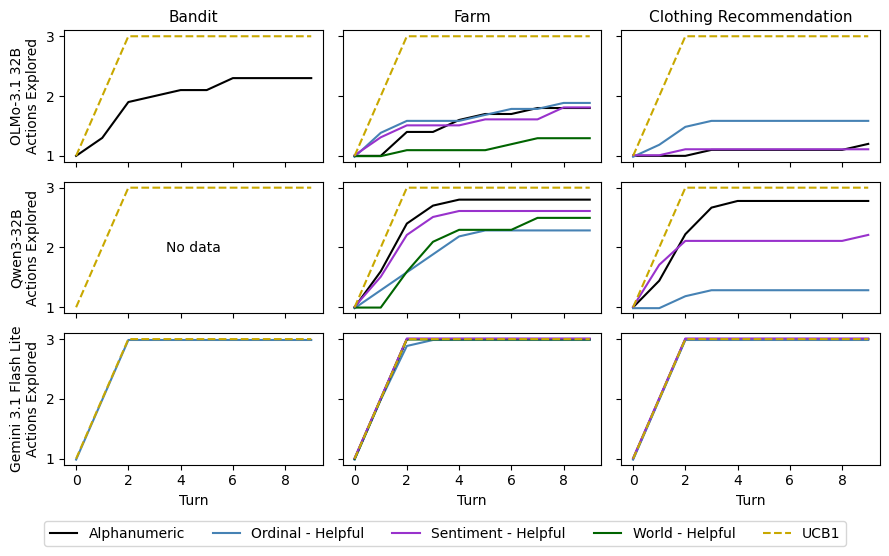

  Saved exploration_count: variance=No


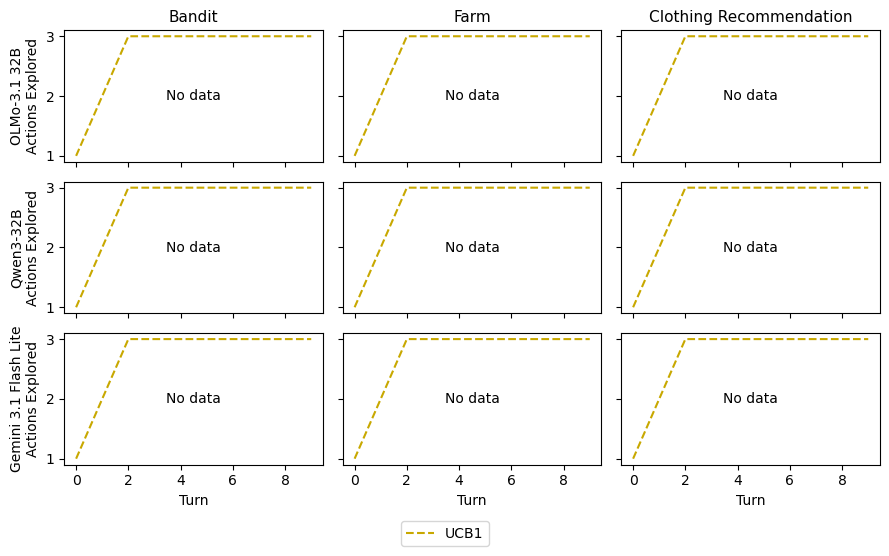

  Saved exploration_count: variance=Low


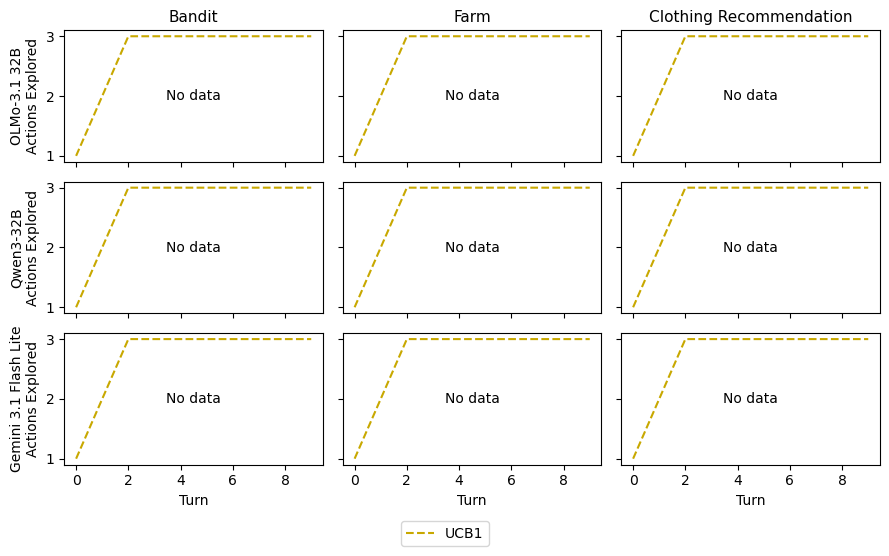

  Saved exploration_count: variance=High


In [9]:
for variance in all_variances:
    plot_exploration_count(
        results_df, variance,
        out_dir     = f'{OUT_BASE}/exploration_count',
        out_dir_png = f'{OUT_BASE_PNG}/exploration_count',
    )

### A3 — Scale Impact on Exploration

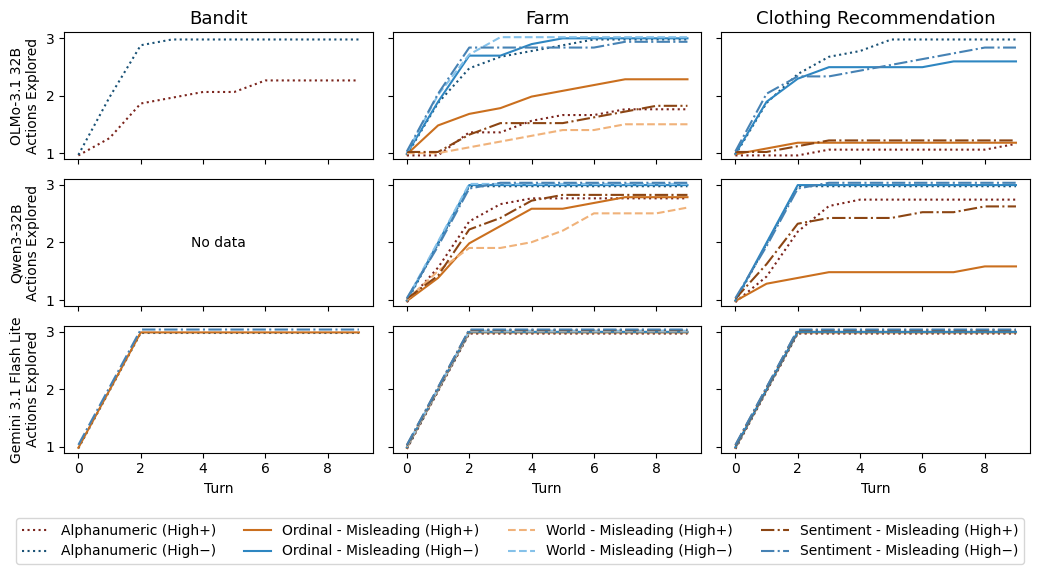

  Saved scale impact: variance=No, scales=high


ValueError: number sections must be larger than 0.

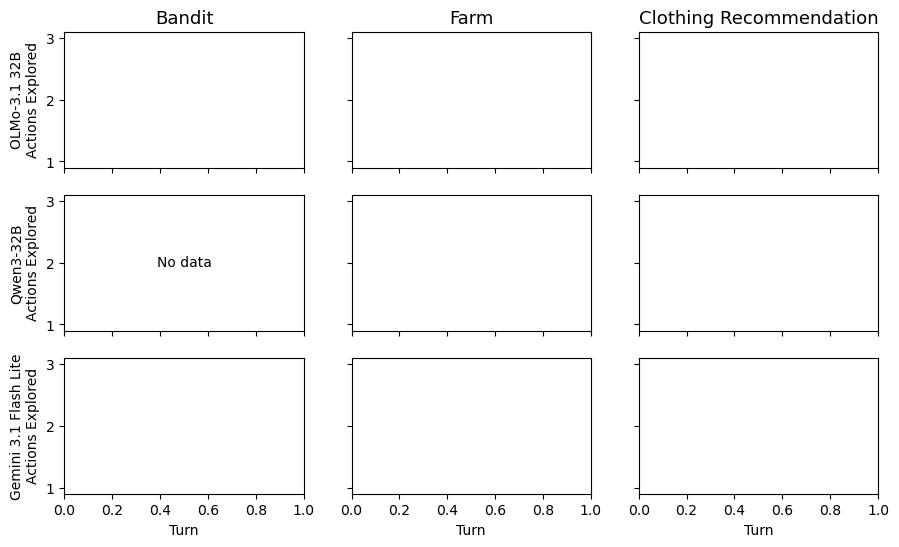

In [10]:
for variance in all_variances:
    for scales_group in SCALE_GROUPS:
        plot_scale_impact(
            results_df, variance, scales_group,
            out_dir     = f'{OUT_BASE}/exploration_count_scale',
            out_dir_png = f'{OUT_BASE_PNG}/exploration_count_scale',
        )

---
# Section B — Explicit Debiasing, With Explore Instruction
(`explicit_debiasing=True`, `explore_instruction=True`)

In [11]:
results_df = _debiased[_debiased['explore_instruction'] == True].copy()
SECTION_LABEL = 'explore_instruction'
SECTION_TITLE = 'With Explore Instruction'
OUT_BASE      = 'figures/explicit_debiasing/explore_instruction'
OUT_BASE_PNG  = 'figures_png/explicit_debiasing/explore_instruction'
print(f"Section B rows: {len(results_df)}")

Section B rows: 228


### B1 — LaTeX Table

In [12]:
table_df, present_doms = make_table_df(results_df)

tabular_all = build_latex_table(table_df, present_doms, include_variance_col=True,
                                scale=SCALE, variance_filter='all')
latex_all   = wrap_table(tabular_all, SCALE, 'all', SECTION_TITLE)
path_all    = f'figures/explicit_debiasing_{SECTION_LABEL}_table_varAll_scale{SCALE}.tex'
with open(path_all, 'w') as f:
    f.write(latex_all)
print(f'Saved: {path_all}\n')
print(latex_all)

df_no_var   = table_df[table_df['Variance'] == 'No'].copy()
tabular_no  = build_latex_table(df_no_var, present_doms, include_variance_col=False,
                                scale=SCALE, variance_filter='No')
latex_no    = wrap_table(tabular_no, SCALE, 'No', SECTION_TITLE)
path_no     = f'figures/explicit_debiasing_{SECTION_LABEL}_table_varNo_scale{SCALE}.tex'
with open(path_no, 'w') as f:
    f.write(latex_no)
print(f'\nSaved: {path_no}\n')
print(latex_no)

Saved: figures/explicit_debiasing_explore_instruction_table_varAll_scalehigh_scale.tex

\begin{table}[ht]
\centering
\small
\resizebox{\columnwidth}{!}{%
\begin{tabular}{llr|rr|rr|rr}
\toprule
 &  &  & \multicolumn{2}{c}{Bandit} & \multicolumn{2}{c}{Farm} & \multicolumn{2}{c}{Clothing} \\
\cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Model & Variance & Nomenclature & Helpful & Misleading & Helpful & Misleading & Helpful & Misleading \\
\midrule
Qwen3-32B & No & Ordinal & 0.17 & \textbf{0.24} & 0.21 & 0.24 & 0.17 & 0.19 \\
 &  & World & -- & -- & \textbf{0.17} & \textbf{0.27} & \textbf{0.15} & \textbf{0.50} \\
 &  & Sentiment & 0.20 & \textbf{0.24} & 0.21 & 0.18 & 0.18 & 0.24 \\
 &  & Alphanumeric & \textbf{0.15} & -- & 0.20 & -- & 0.16 & -- \\
 & Low & Ordinal & -- & -- & -- & -- & -- & -- \\
 &  & World & -- & -- & -- & -- & -- & -- \\
 &  & Sentiment & -- & -- & -- & -- & -- & -- \\
 &  & Alphanumeric & -- & -- & -- & -- & -- & -- \\
 & High & Ordinal & -- & -- & -- & -- &

### B2 — Exploration Count (Three-Model)

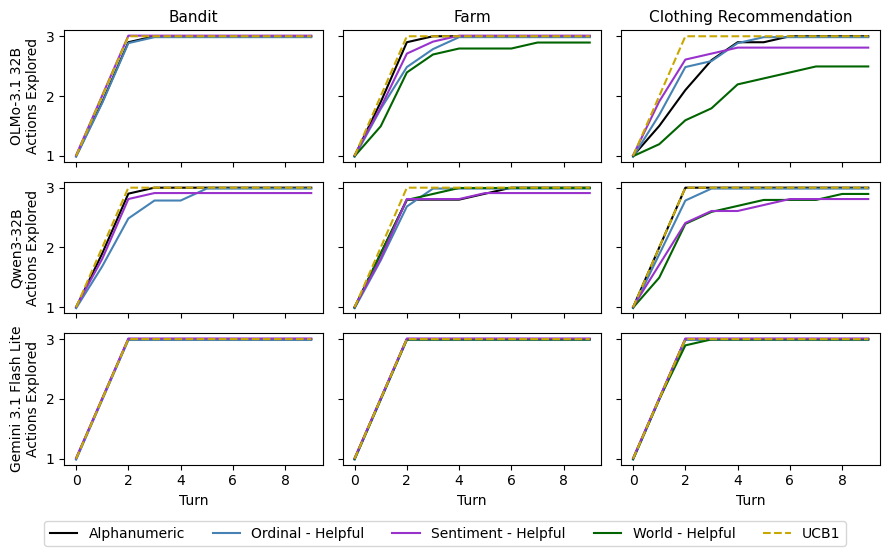

  Saved exploration_count: variance=No


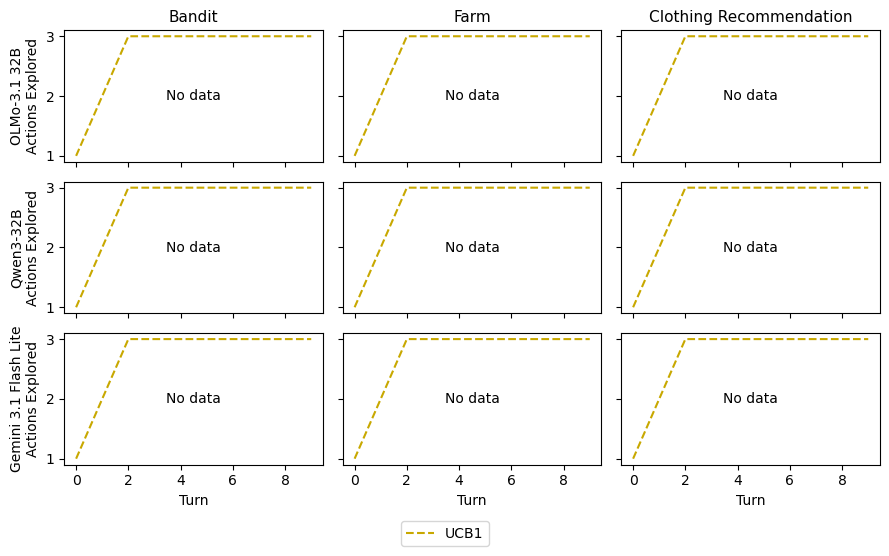

  Saved exploration_count: variance=Low


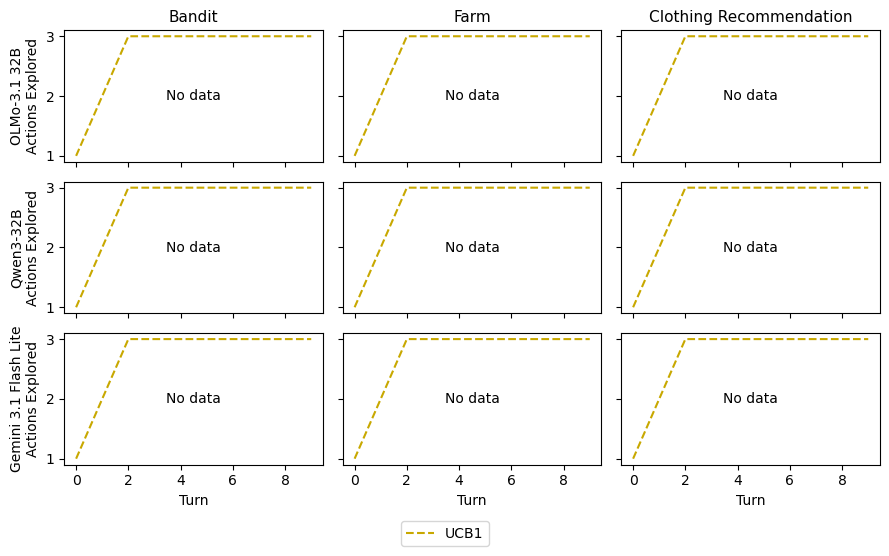

  Saved exploration_count: variance=High


In [13]:
for variance in all_variances:
    plot_exploration_count(
        results_df, variance,
        out_dir     = f'{OUT_BASE}/exploration_count',
        out_dir_png = f'{OUT_BASE_PNG}/exploration_count',
    )

### B3 — Scale Impact on Exploration

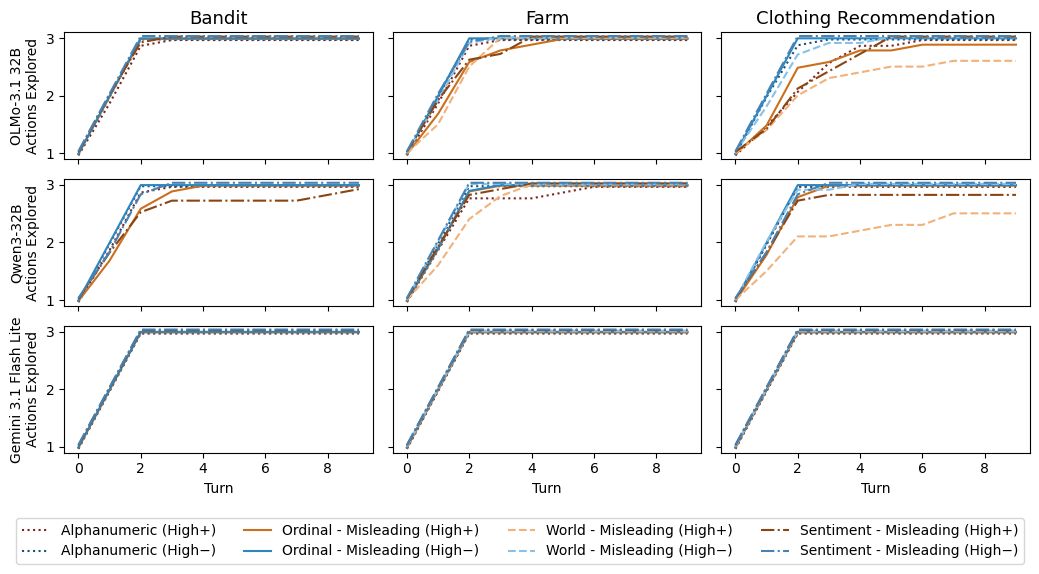

  Saved scale impact: variance=No, scales=high


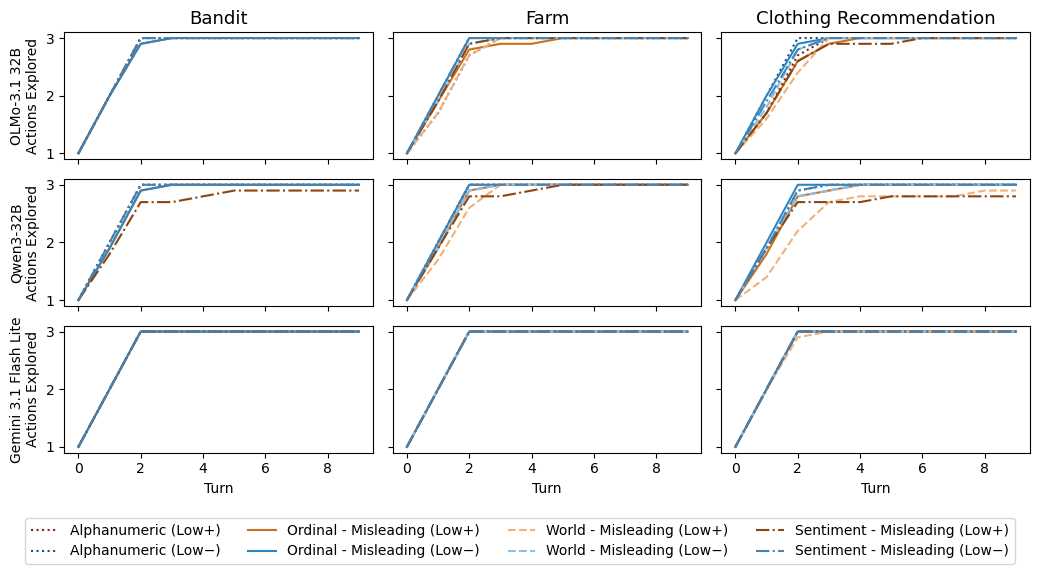

  Saved scale impact: variance=No, scales=low


ValueError: number sections must be larger than 0.

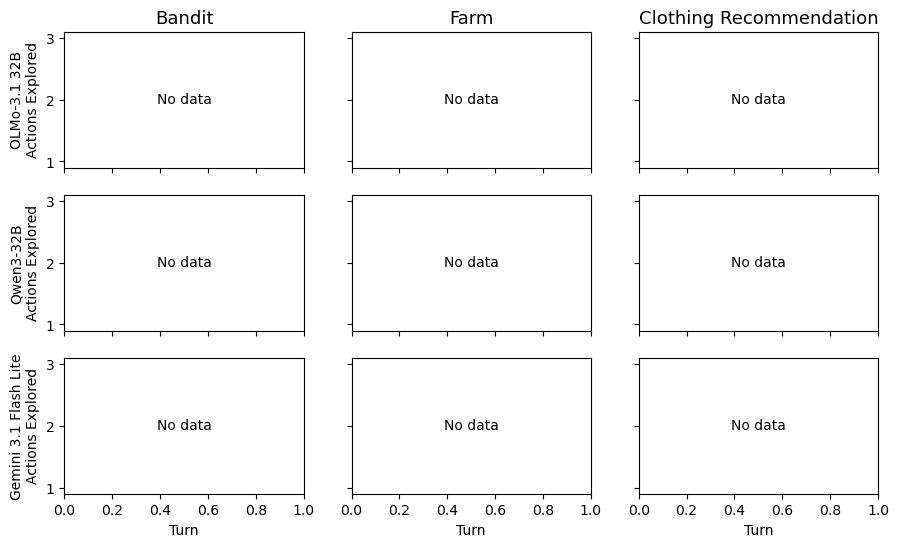

In [14]:
for variance in all_variances:
    for scales_group in SCALE_GROUPS:
        plot_scale_impact(
            results_df, variance, scales_group,
            out_dir     = f'{OUT_BASE}/exploration_count_scale',
            out_dir_png = f'{OUT_BASE_PNG}/exploration_count_scale',
        )